# 🐼 Pandas: Data Analysis and Manipulation

Welcome to the comprehensive guide to **Pandas**. This notebook covers everything from basic data structures to advanced data cleaning and analysis techniques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setting display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 🛠️ Phase 1: Foundations
### 1.1 Creating Series
A **Series** is a 1-D array-like structure. It can hold any data type and can be created from lists, dictionaries, or tuples.

In [2]:
# Creating series from various data structures
data_list = [1, 2, 3, 5, 6, 7]
data_dict = {"one": 1, "two": 2, "three": 3, "four": 4}

series_from_list = pd.Series(data_list)
series_from_dict = pd.Series(data_dict)

print("Series from List:\n", series_from_list)
print("\nSeries from Dict:\n", series_from_dict)

# Custom Indexing
custom_series = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print("\nCustom Indexed Series:\n", custom_series)

Series from List:
 0    1
1    2
2    3
3    5
4    6
5    7
dtype: int64

Series from Dict:
 one      1
two      2
three    3
four     4
dtype: int64

Custom Indexed Series:
 a    10
b    20
c    30
dtype: int64


### 1.2 DataFrames
A **DataFrame** is a 2-D labeled data structure with columns of potentially different types. It's the most commonly used Pandas object.

In [3]:
# Creating a DataFrame from a dictionary
data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [25, 30, 35, 40],
    "City": ["New York", "London", "Paris", "Tokyo"]
}

df_basic = pd.DataFrame(data)
print("Basic DataFrame:\n", df_basic)

Basic DataFrame:
       Name  Age      City
0    Alice   25  New York
1      Bob   30    London
2  Charlie   35     Paris
3    David   40     Tokyo


### 1.3 Loading Data
Pandas supports reading data from various formats like CSV, JSON, Excel, and SQL.

In [4]:
# Loading from CSV
df = pd.read_csv("goals.csv")

# Basic Inspection
print("First 5 rows:\n", df.head())
print("\nDataset Info:")
df.info()

First 5 rows:
   GOAL_ID MATCH_ID      PID  DURATION  ASSIST          GOAL_DESC
0   gl470    mt154  ply1479         4  ply864  right-footed shot
1   gl471    mt154  ply1075        28  ply864            penalty
2   gl472    mt154   ply585        69  ply864  right-footed shot
3   gl473    mt155   ply396        12  ply653  right-footed shot
4   gl474    mt155  ply1064        81  ply653  right-footed shot

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2279 entries, 0 to 2278
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   GOAL_ID    2279 non-null   object
 1   MATCH_ID   2279 non-null   object
 2   PID        2176 non-null   object
 3   DURATION   2279 non-null   int64 
 4   ASSIST     1605 non-null   object
 5   GOAL_DESC  2263 non-null   object
dtypes: int64(1), object(5)
memory usage: 107.0+ KB


## 🧹 Phase 2: Data Cleaning
Real-world data is often messy. Cleaning involves handling missing values, duplicates, and incorrect types.

In [5]:
# Checking for missing values
print("Missing values per column:\n", df.isnull().sum())

# Filling missing values in 'ASSIST' with a placeholder
df['ASSIST'] = df['ASSIST'].fillna('None')

# Dropping rows with missing 'PID' (if they are critical)
df_clean = df.dropna(subset=['PID'])

# Removing duplicates
df_clean = df_clean.drop_duplicates()

print("\nShape after cleaning:", df_clean.shape)

Missing values per column:
 GOAL_ID        0
MATCH_ID       0
PID          103
DURATION       0
ASSIST       674
GOAL_DESC     16
dtype: int64

Shape after cleaning: (2176, 6)


## 🔧 Phase 3: Data Manipulation
This includes filtering, adding new columns, and transforming existing data.

In [6]:
# Boolean Indexing (Filtering)
header_goals = df[df['GOAL_DESC'] == 'header']
long_duration = df[df['DURATION'] > 80]

# Adding a new column (e.g., categorizing duration)
df['TIME_CATEGORY'] = df['DURATION'].apply(lambda x: 'First Half' if x <= 45 else 'Second Half')

print("Data with new column:\n", df[['DURATION', 'TIME_CATEGORY']].head())

Data with new column:
    DURATION TIME_CATEGORY
0         4    First Half
1        28    First Half
2        69   Second Half
3        12    First Half
4        81   Second Half


## 🧬 Phase 4: Advanced Analysis
Grouping data and performing aggregations to find insights.

In [7]:
# Grouping by Goal Description and calculating average duration
stats = df.groupby('GOAL_DESC')['DURATION'].agg(['count', 'mean', 'max'])
print("Goal Statistics:\n", stats.sort_values(by='count', ascending=False).head())

# Pivot Table: Goals by Match and Description (Subset)
pivot = df.pivot_table(index='MATCH_ID', columns='GOAL_DESC', values='GOAL_ID', aggfunc='count').fillna(0)
print("\nPivot Table (Preview):\n", pivot.iloc[:5, :5])

Goal Statistics:
                    count       mean  max
GOAL_DESC                               
right-footed shot    956  50.788703  112
left-footed shot     632  50.416139  120
header               323  48.359133  117
penalty              223  50.103139  117
own goal              71  46.760563   90

Pivot Table (Preview):
 GOAL_DESC  back heel  bicycle kick  free kick  header  ind. free kick
MATCH_ID                                                             
mt1              0.0           0.0        0.0     3.0             0.0
mt10             0.0           0.0        0.0     1.0             0.0
mt100            0.0           0.0        0.0     1.0             0.0
mt101            0.0           0.0        0.0     1.0             0.0
mt102            0.0           0.0        0.0     0.0             0.0


## 📊 Phase 5: Visualization
Quickly visualizing patterns within the data using Pandas' built-in plotting.

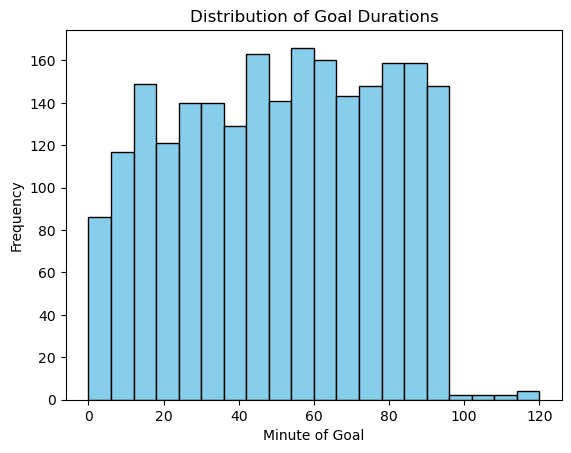

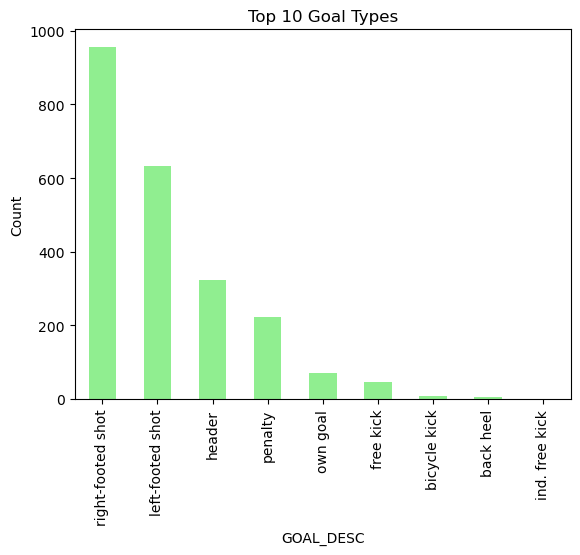

In [8]:
# Plotting the distribution of goal durations
df['DURATION'].plot(kind='hist', bins=20, title='Distribution of Goal Durations', color='skyblue', edgecolor='black')
plt.xlabel('Minute of Goal')
plt.show()

# Counting types of goals
df['GOAL_DESC'].value_counts().head(10).plot(kind='bar', title='Top 10 Goal Types', color='lightgreen')
plt.ylabel('Count')
plt.show()